# Understanding `NeighborPairs`

`NeighborPairs` is the central object in `Lahuta`. It stores information on neighboring atoms. <br>
The contacts API is designed to act on `NeighborPairs` objects and return `NeighborPairs` objects. This syntax allows for easy chaining of operations. 

In [2]:
from lahuta import Luni
from lahuta.contacts import F

In [3]:
# Read in the structure (it should have been downloaded in the previous tutorial)
luni = Luni('data/2rh1.pdb')

## Note 1: Computing neighbors is very fast! 

In [4]:
# Compute the neighbors
# We compute the neighbors for different radii and resolution differences
ns1 = luni.neighbors(radius=5.0, res_dif=4)
ns2 = luni.neighbors(radius=5.0, res_dif=0)
ns3 = luni.neighbors(radius=4.0, res_dif=2)
ns4 = luni.neighbors(radius=6.0, res_dif=2)

# Print the number of neighbors
print(f'Number of neighbors for radius=5.0, res_dif=4: {len(ns1)}')
print(f'Number of neighbors for radius=5.0, res_dif=0: {len(ns2)}')
print(f'Number of neighbors for radius=4.0, res_dif=2: {len(ns3)}')
print(f'Number of neighbors for radius=6.0, res_dif=2: {len(ns4)}')

Number of neighbors for radius=5.0, res_dif=4: 8866
Number of neighbors for radius=5.0, res_dif=0: 45466
Number of neighbors for radius=4.0, res_dif=2: 5141
Number of neighbors for radius=6.0, res_dif=2: 36745


Notice how not filtering neighboring atoms by residue difference (res_dif=0) results in a much larger number of neighbors. <br>
This is because the majority of close atoms are in the same residue or with neighboring residues. <br>

Also notice how using a large cutoff radius (radius=6.0) also results in a much larger number of neighbors. <br>

## Note 2: Comparing NeighborPairs

In [5]:
# Get neighboring atoms 0-3 residues apart
ns2 - ns1

<Lahuta NeighborPairs class containing 3760 atoms and 36600 pairs>

In [6]:
# Get neighboring atoms less than 6 and more than 4 Angstrom apart
ns4 - ns3

<Lahuta NeighborPairs class containing 3753 atoms and 31604 pairs>

In [7]:
# ns3 is a subset of ns4, as is ns1 of ns2
ns3 <= ns4, ns1 <= ns2

(True, True)

In [8]:
# ns2 is not a subset of ns1 because ns2 also contains atoms between neighboring residues
ns2 <= ns1

False

## Note 3: You can access atom information NeighborPairs. 

In [9]:
# atom indices along with their distances
ns1.pairs, ns1.distances

(array([[  24,   61],
        [  33,  496],
        [  33,  513],
        ...,
        [3783, 3803],
        [3787, 3803],
        [3789, 3803]]),
 array([4.73189541, 4.42905811, 4.45965022, ..., 4.67188968, 3.54749682,
        2.78203339]))

In [10]:
# indexing produces a new NeighborPairs object
ns1_03 = ns1[0:3]

In [11]:
ns1_03.pairs, ns1_03.distances

(array([[ 24,  61],
        [ 33, 496],
        [ 33, 513]]),
 array([4.73189541, 4.42905811, 4.45965022]))

In [12]:
ns1.atoms[ns1_03.pairs]

<AtomGroup with 3 atoms>

# Note 4: The contacts interface is like a filter for the NeighborPairs object

In [13]:
F.aromatic_neighbors(ns1)

<Lahuta NeighborPairs class containing 66 atoms and 64 pairs>

In [14]:
F.vdw_neighbors(ns1)

<Lahuta NeighborPairs class containing 206 atoms and 117 pairs>

In [15]:
# Get the union of aromatic and van der Waals neighbors (i.e. all pairs of atoms that are either aromatic or van der Waals neighbors)
F.aromatic_neighbors(ns1) + F.vdw_neighbors(ns1)

<Lahuta NeighborPairs class containing 265 atoms and 178 pairs>

In [16]:
# compute aromatic neighbors with a distance cutoff of 4.5 and 5 Angstrom and take the difference 
# (i.e. the pairs of atoms that are aromatic neighbors at 5 Angstrom but not at 4.5 Angstrom)
F.aromatic_neighbors(ns1, distance=5) - F.aromatic_neighbors(ns1, distance=4.5)

<Lahuta NeighborPairs class containing 135 atoms and 131 pairs>

In [17]:
# Get atoms that are both aromatic and van der Waals neighbors (i.e. the intersection of aromatic and van der Waals neighbors)
F.aromatic_neighbors(ns1) & F.vdw_neighbors(ns1)

<Lahuta NeighborPairs class containing 6 atoms and 3 pairs>

## Note 5: Set operations on NeighborPairs

See the [documentation](https://bisejdiu.github.io/lahuta/usage/arithmetic/) for more information on set operations.

In [18]:
ns1.union(ns2).intersection(ns3).symmetric_difference(ns4)

<Lahuta NeighborPairs class containing 3753 atoms and 31604 pairs>

In [19]:
ns1 + ns2 & ns3 | ns4

<Lahuta NeighborPairs class containing 3753 atoms and 31604 pairs>

## Note 6: NeighborPairs resulting from the same vs. different protein structures¶

The discussion here focusses on `NeighborPairs` objects resulting from the same protein structure. <br>
However, `NeighborPairs` objects resulting from different protein structures can also be compared, albeit with a slight complication. <br>

This is described further in later notebooks.

## Note 7: The content of NeighborPairs objects can be viewed as a pandas DataFrame

In [20]:
ns1.to_frame()

,partner1_resids,partner1_resnames,partner1_names,partner1_indices,partner2_resids,partner2_resnames,partner2_names,partner2_indices,distances
0,32,TRP,O,24,37,GLY,N,61,4.731895
1,32,TRP,CZ3,33,95,LEU,CD2,496,4.429058
2,32,TRP,CZ3,33,97,LYS,NZ,513,4.459650
3,32,TRP,CH2,34,95,LEU,CD2,496,4.783753
4,33,VAL,CA,36,95,LEU,CD2,496,4.232306
...,...,...,...,...,...,...,...,...,...
8861,514,HOH,O,3769,530,HOH,O,3785,2.998741
8862,526,HOH,O,3781,531,HOH,O,3786,2.792991
8863,528,HOH,O,3783,548,HOH,O,3803,4.671890
8864,532,HOH,O,3787,548,HOH,O,3803,3.547497


In [21]:
ns3.to_frame(df_format='compact')

,partner1,partner2,distances
0,29-ASP-O-3,32-TRP-CB-25,3.612758
1,29-ASP-O-3,33-VAL-CG2-41,3.992288
2,30-GLU-C-7,33-VAL-N-35,3.648749
3,30-GLU-O-8,33-VAL-N-35,2.937284
4,30-GLU-O-8,33-VAL-CA-36,3.506643
...,...,...,...
5136,514-HOH-O-3769,530-HOH-O-3785,2.998741
5137,526-HOH-O-3781,531-HOH-O-3786,2.792991
5138,532-HOH-O-3787,548-HOH-O-3803,3.547497
5139,534-HOH-O-3789,548-HOH-O-3803,2.782033


In [22]:
F.plane_plane_neighbors(ns1).to_frame(annotations=True).head(5)

,partner1_resids,partner1_resnames,partner1_names,partner1_indices,partner2_resids,partner2_resnames,partner2_names,partner2_indices,distances,theta_angles,normal_angles,ring1_atoms,ring2_atoms,contact_labels
0,32,TRP,CD1,27,32,TRP,NE1,29,2.163306,89.990570,0.000000,"[27, 28, 29, 30, 31]","[29, 31, 32, 33, 34, 35]",EE
1,89,PHE,CD1,452,101,PHE,CD1,549,4.699532,6.997678,53.057976,"[549, 550, 551, 552, 553, 554]","[452, 453, 454, 455, 456, 457]",FT
2,89,PHE,CD1,452,105,TRP,CD1,583,4.594414,61.439877,81.773392,"[583, 584, 585, 586, 587]","[452, 453, 454, 455, 456, 457]",EF
3,89,PHE,CD1,452,105,TRP,NE1,585,5.380479,65.917130,81.822083,"[585, 587, 588, 589, 590, 591]","[452, 453, 454, 455, 456, 457]",EF
4,93,HIS,ND1,477,99,TRP,NE1,530,5.397205,20.503235,87.817032,"[477, 478, 479, 480, 481]","[530, 532, 533, 534, 535, 536]",FE


## Note 8: Exporting contacts to a csv, html, etc. file

`Lahuta` provides support for visualizing `NeighborPairs` as a pandas DataFrame. Export functionality is deferred to pandas. <br>

In [23]:
df = F.plane_plane_neighbors(ns1).to_frame(annotations=True)
df = df[df['distances'] > 4]

# Different output formats
# df.to_csv('plane_plane_neighbors.csv')
# df.to_excel('plane_plane_neighbors.xlsx')
# df.to_html('plane_plane_neighbors.html')
# df.to_json('plane_plane_neighbors.json')

## Note 9: Visualize neighbors as a contact maps

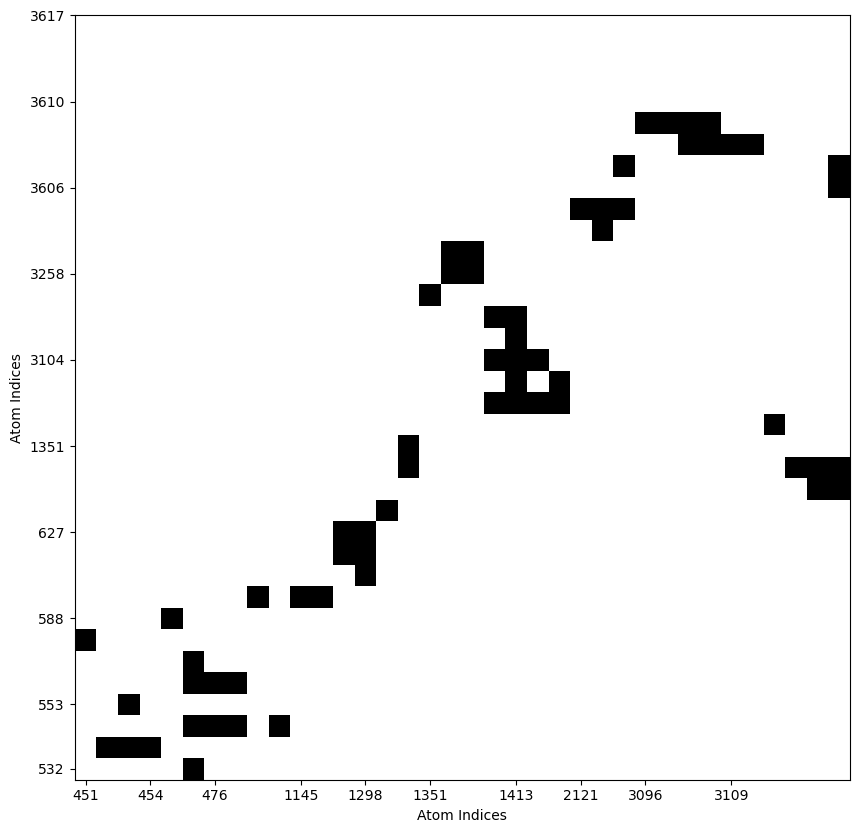

In [24]:
F.aromatic_neighbors(ns1).plot()

## Note 10: Exporting contacts to VMD, PyMOL, etc.

In [25]:
# The script below visualizes the computed neighbors in VMD
carbon_pi = F.carbon_pi(ns3)
print(carbon_pi.vmd_exporter())

proc draw_interaction {atom1_index atom2_index sphere_resolution} {

    set atom1 [atomselect top "index $atom1_index"]
    set atom2 [atomselect top "index $atom2_index"]

    set coord [$atom1 get {x y z}]
    set coord [string trim $coord "{}"]
    lassign [split $coord] x1 y1 z1

    set coord [$atom2 get {x y z}]
    set coord [string trim $coord "{}"]
    lassign [split $coord] x2 y2 z2

    graphics top cylinder [list $x1 $y1 $z1] [list $x2 $y2 $z2] radius 0.1
}

proc draw_interactions {index_pairs sphere_resolution} {
    foreach pair $index_pairs {
        draw_interaction top [lindex $pair 0] [lindex $pair 1] $sphere_resolution
    }
}

draw_interactions top {{29 57} {29 58} {3302 87} {3490 182} {238 228} {3455 270} {315 922} {327 749} {528 1281} {583 621} {1070 642} {3606 664} {3606 665} {3606 666} {3065 686} {3067 686} {1012 699} {796 832} {872 2927} {1131 1111} {1348 1140} {1348 1143} {1145 1152} {1145 1155} {1145 1156} {1235 1156} {1235 1157} {1180 1206} {1308 1203} {129